In [ ]:
# !pip install catboost plotly

[Данные](https://disk.yandex.ru/d/4lMVoeaAKI11Lg)

# Обработка лидарных данных
## Сегментация

### Про лидар

![](https://realnoevremya.com/uploads/gallery/b9/7e/35d10da899958110.jpg)

In [ ]:
from IPython.lib.display import YouTubeVideo
YouTubeVideo('Pa-q5elS_nE')

## А что за данные на самом деле


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import plotly.offline as py
import plotly.figure_factory as ff
import plotly.graph_objs as go
import tqdm
py.init_notebook_mode(connected=True)

EQUAL_ASPECT_RATIO_LAYOUT = dict(
    margin={
        'l': 0,
        'r': 0,
        'b': 0,
        't': 0
    }, scene=dict(
    aspectmode='data'
))


def color(x, cmap='Reds'):
    cmap = plt.get_cmap(cmap)
    x = (x - np.min(x)) / np.max(x)
    
    return cmap(x)

%matplotlib inline

In [ ]:
ds = pd.read_csv('snow/snow.csv')
ds = ds.set_index(['scene_id'])
ds.head()

* intensity - ???
* ring - ???

### Кольцо

![](https://eckop.com/wp-content/uploads/2018/07/LIDAR_02-1024x366.png)

In [ ]:
scene = ds.loc[10]

fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': scene.x,
    'y': scene.y,
    'z': scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(scene.ring, 'tab20'),
    },
    'text': scene.ring
})

py.iplot(fig)


### Интенсивность

![](https://res.mdpi.com/sensors/sensors-15-28099/article_deploy/html/images/sensors-15-28099-g001-1024.png)

### Как можно использовать?
![](https://cdn.ncbi.nlm.nih.gov/pmc/blobs/73bf/4701271/416a03b48367/sensors-15-28099-g003.jpg)

Example applications of LIDAR intensity. 
- (a) Intensity image from ALS data;
- (b) intensity shaded point cloud showing damage to concrete in a tunnel (data courtesy of Oregon DOT);
- (c) Intensity shaded point cloud showing pavement lines and striping;
- (d) corrected bottom intensity image for mapping seafloor;
- (e) intensity colored point cloud showing different geologic layers in a cliff;
- (f) detection of reflective signs based on intensity values; 
- (g) intensity colored point cloud showing damage to concrete walls after an earthquake; 
- (h) intensity-colored point cloud point cloud showing damage to roof cladding after a tornado.

Read more at https://pmc.ncbi.nlm.nih.gov/articles/PMC4701271/

## Сборник интересных эффектов
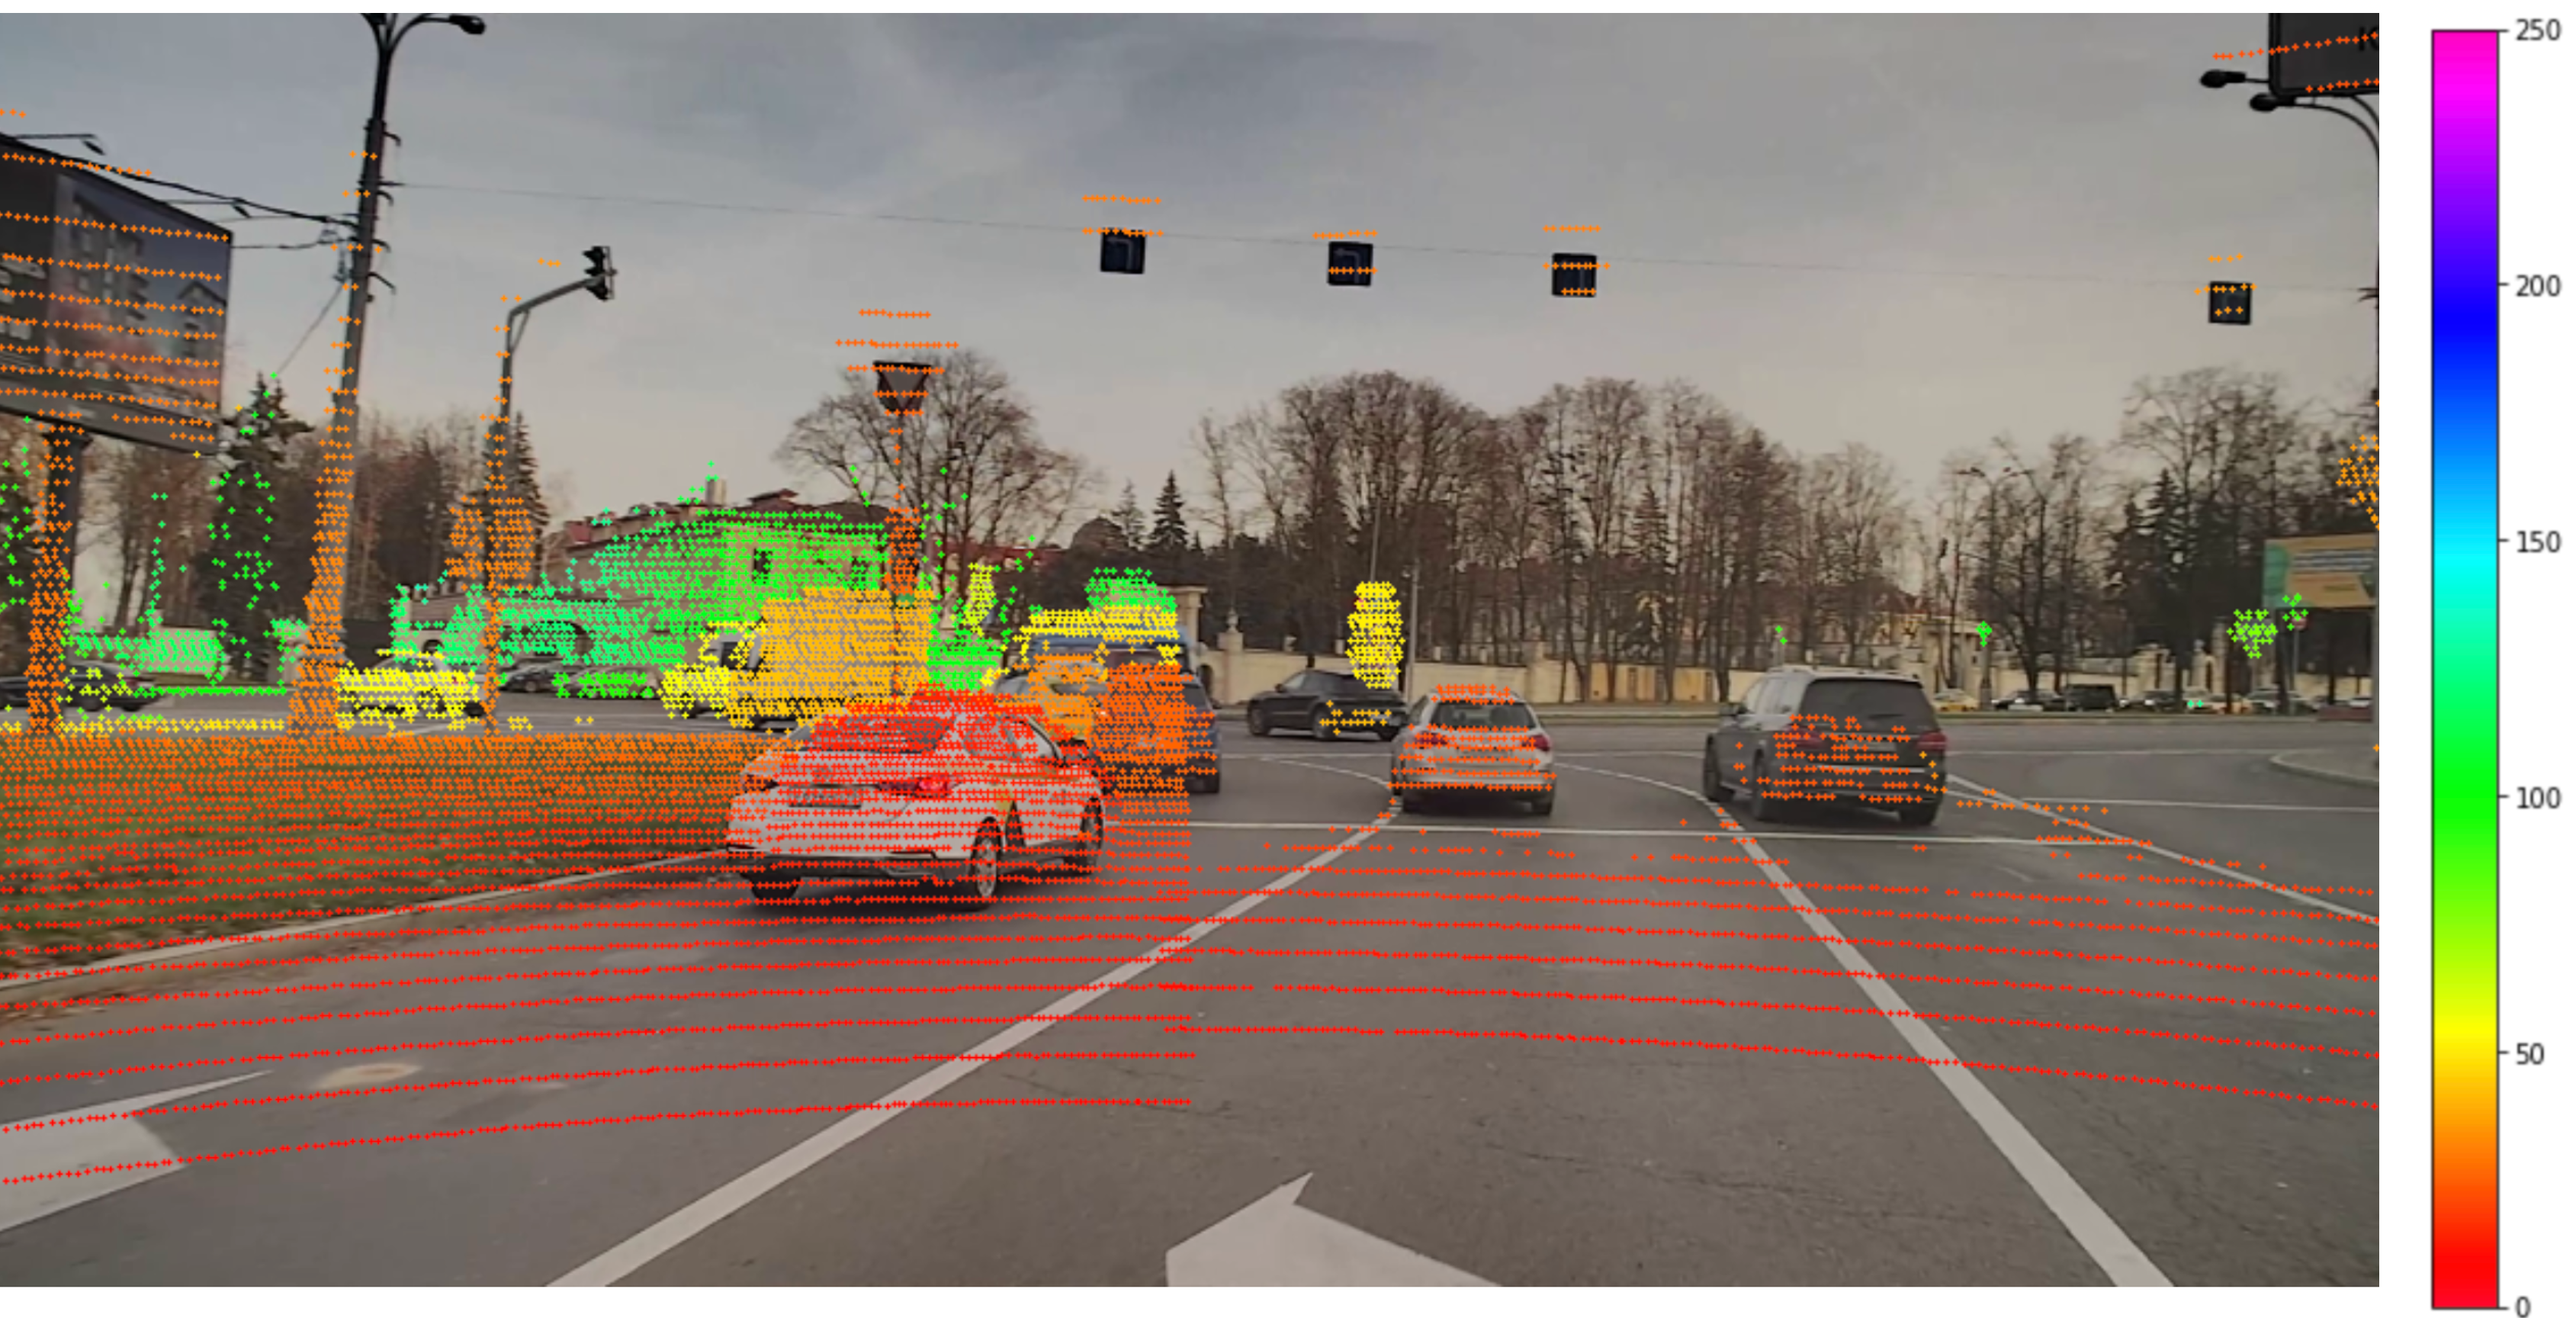

In [ ]:
fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': scene.x,
    'y': scene.y,
    'z': scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(scene.intensity, 'seismic'),
    },
    'text': scene.intensity
})

py.iplot(fig)

In [ ]:
fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': scene.x,
    'y': scene.y,
    'z': scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(scene.label, 'seismic'),
    },
    'text': scene.label
})

py.iplot(fig)


# Отфильтруем снег

## Эвристикой

In [ ]:
def filter_by_intensity(intensity, limit=3):
    pass  #TODO

filtered_scene = scene[filter_by_intensity(scene.intensity)]

fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': filtered_scene.x,
    'y': filtered_scene.y,
    'z': filtered_scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(filtered_scene.intensity, 'seismic'),
    },
    'text': filtered_scene.intensity
})

py.iplot(fig)

In [ ]:
filtered_scene = scene[~filter_by_intensity(scene.intensity, 2)]

fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': filtered_scene.x,
    'y': filtered_scene.y,
    'z': filtered_scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(filtered_scene.label, 'seismic'),
    },
    'text': filtered_scene.label
})

py.iplot(fig)

Часть шума остается. При этом есть опасность, что мы вырежем что-то важное.

## Вычисления на облаках точек

In [ ]:
from sklearn.neighbors import KDTree

class ComputeFeatures(object):
    def __init__(self, r=1.0):
        self.xyz = None
        self.intensity = None
        self.ring = None
        self.index = None
        self.r = r

    def _feature_names(self):
        return [x.format(self.r) for x in [
            "min_intensity_{}", "max_intensity_{}", "median_intensity_{}", "std_intensity_{}",
            "min_ring_{}", "max_ring_{}", "median_ring_{}", "std_ring_{}",
            "r_std_{}",
            "n_neighbors_{}"]] + ["intensity", "ring"]

        
    def compute_point_features(self, point_id, neighbors):
        # return list of features for given neighbors
        if len(neighbors) > 0:
            xyz_n, intensity_n, ring_n = self.xyz[neighbors], self.intensity[neighbors], self.ring[neighbors]

            rel_xyz = xyz_n - self.xyz[point_id][np.newaxis, :]
            rel_r = np.linalg.norm(rel_xyz, axis=1) / np.linalg.norm(self.xyz[point_id])
        
            return [
                np.min(intensity_n), np.max(intensity_n), np.median(intensity_n), np.std(intensity_n), 
                np.min(ring_n), np.max(ring_n), np.median(ring_n), np.std(ring_n),
                np.std(rel_r),
                len(neighbors),
                self.intensity[point_id], self.ring[point_id]
            ]
        else:
            return [
                0, 0, 0, 0,
                0, 0, 0, 0,
                0,
                len(neighbors),
                self.intensity[point_id], self.ring[point_id]
            ]
                
    
    def get_point_neighbors(self, point_id):
        return self.index.query_radius(self.xyz[point_id][np.newaxis, :], r=self.r)[0]
        
    def __call__(self, xyz, intensity, ring):
        self.xyz = xyz[:]
        self.intensity = intensity[:]
        self.ring = ring[:]
        
        self.index = KDTree(self.xyz)
        
        features = [] # TODO: make features

        return pd.DataFrame(columns=self._feature_names(), data=features)
    


In [ ]:
import os
os.mkdir('features')

In [ ]:
features = ComputeFeatures(r=1.0)

for scene_id in tqdm.tqdm(ds.reset_index().scene_id.unique()):
    scene = ds.loc[scene_id]
    features_df = \
        features(scene[['x', 'y', 'z']].values, scene.intensity.values, scene.ring.values)
    features_df.to_csv('./features/{}.csv'.format(scene_id))

In [ ]:
ds_features = []
for scene in os.listdir('features'):
    scene_features = pd.read_csv(os.path.join('features', scene))
    scene_id = int(scene.split('.')[0])
    scene_features['scene_id'] = scene_id
    scene_features['label'] = ds.loc[scene_id].label.values
    ds_features.append(scene_features)

In [ ]:
ds_features = pd.concat(ds_features)

In [ ]:
ds_features = ds_features.drop(['Unnamed: 0'], axis=1)

In [ ]:
ds_features.head()

# Посмотрим на разметку

In [ ]:
scene = ds.loc[1]

fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': scene.x,
    'y': scene.y,
    'z': scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(scene.label, 'seismic'),
    },
    'text': scene.label
})

py.iplot(fig)

## Поучим что-нибудь

In [ ]:
# TODO train test split, but how

train = None
test = None
val = None

In [ ]:
import catboost

def learn(X_train, X_val, y_train, y_val):
    clf = catboost.CatBoostClassifier(n_estimators=100)
    clf.fit(
        X_train, y_train, early_stopping_rounds=10,
        use_best_model=True, eval_set=(X_val.values, y_val.values), plot=True, verbose=False)
    return clf

X_train = train.drop(["scene_id", "label"], axis=1)
y_train = train.label


X_val = val.drop(["scene_id", "label"], axis=1)
y_val = val.label

In [ ]:
cls = learn(X_train, X_val, y_train, y_val)

In [ ]:
X_test = test.drop(['scene_id', 'label'], axis=1)
y_test = test.label

from sklearn.metrics import precision_recall_curve, precision_score, recall_score

def test_one(clf, X_test, y_test):
    y_test_hat = clf.predict_proba(X_test)
    pr, rec, thr = precision_recall_curve(y_test, y_test_hat[:, 1])
    ix = np.linspace(1, len(pr) - 1, num=2000).astype(int)
    return pr[ix], rec[ix], thr[ix - 1]


def heuristic_filter_scoring():
    pr = []
    rec = []
    filter_range = range(1, 10)
    for i in filter_range:
        y_test_heuristic_hat = np.ones(len(X_test))
        y_test_heuristic_hat[filter_by_intensity(test.intensity, i)] = 0
        pr.append(precision_score(y_test, y_test_heuristic_hat))
        rec.append(recall_score(y_test, y_test_heuristic_hat))
        
    return pr, rec, filter_range


pr_bl, rec_bl, thr_bl = heuristic_filter_scoring()


def plot_pr_rec(*models):
    traces = []
    for model, clf, X_test, y_test in models:
        pr, rec, thr = test_one(clf, X_test, y_test)
        pr_rec = go.Scattergl(x = rec, y = pr, mode='lines', text=thr, name=model)
        traces.append(pr_rec)

    pr_rec_bl = go.Scatter(x = rec_bl, y = pr_bl, mode='lines+markers', name='Intensity BL')

    layout = go.Layout(
        title='Precision Recall Curve',
        xaxis=dict(
            title='Recall'
        ),
        yaxis=dict(
            title='Precission'
        ))
    fig = go.Figure(
        data=traces + [pr_rec_bl],
        layout=layout)
    py.iplot(fig)

models = [('Catboost classifier', cls, X_test, y_test)]
plot_pr_rec(*models)

# Повизуализируем

In [ ]:
y_test_hat = cls.predict_proba(test.drop(['scene_id', 'label'], axis=1))

In [ ]:
scene_id = 190
scene = ds.loc[scene_id]
scene_predictions = y_test_hat[test.scene_id == scene_id][:, 1]

In [ ]:
ds.loc[190]

In [ ]:
fig = go.Figure(layout=EQUAL_ASPECT_RATIO_LAYOUT)
fig.add_scatter3d(**{
    'x': scene.x,
    'y': scene.y,
    'z': scene.z,
    'mode': 'markers',
    'marker': {
        'size': 1,
        'color': color(scene_predictions, 'seismic'),
    },
    'text': scene_predictions
})

py.iplot(fig)